# 04 - Quanvolutional Neural Networks

This notebook follows the structure of the accompanying presentation **"Quanvolutional neural networks"**:

1. classical convolutional neural networks,
2. convolution arithmetic, padding, stride, channels, and filters,
3. the hybrid QML idea behind quanvolution,
4. a quantum filter implemented with PennyLane,
5. a small applied classification example,
6. practical design knobs and tradeoffs.

The implementation stays close to the previous notebooks: each code cell is self-contained, uses the existing `uv` environment, and avoids high-level model wrappers. The quantum parts use PennyLane as the circuit simulator.


## Classical Convolution Recap

Images and time series are not just flat vectors. They have axes where local ordering matters:

- height and width for images,
- time for signals,
- a channel axis for multiple views of the same location.

A convolutional layer applies a small **kernel** or **filter** across local regions of the input. For a single input channel, a 2D convolution is

$$
Y[u,v]
=
\sum_{a=0}^{k_h-1}
\sum_{b=0}^{k_w-1}
K[a,b]\,
X_{\mathrm{pad}}[u s_h + a, v s_w + b].
$$

Here:

- $K$ is the kernel,
- $s_h, s_w$ are strides,
- $X_{\mathrm{pad}}$ is the padded input,
- $Y$ is the output feature map.

Along one axis, the output size is

$$
\mathrm{out}
=
\left\lfloor
\frac{\mathrm{in} + 2p - k}{s}
\right\rfloor
+ 1,
$$

where $p$ is padding, $k$ is kernel size, and $s$ is stride.


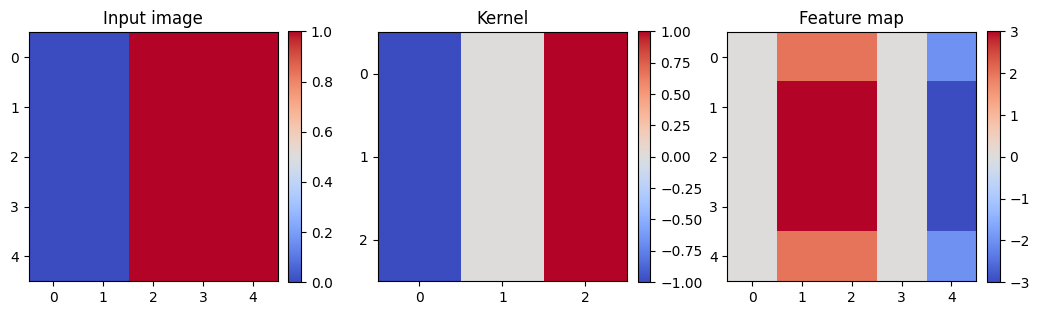

input shape: (5, 5)
kernel shape: (3, 3)
output shape: (5, 5)


In [1]:
# Pseudo-code:
#   1. create a small image and a convolution kernel
#   2. pad the image and slide the kernel over it
#   3. compute the convolution output from local dot products
#   4. visualize input, kernel, and output feature map

# Classical 2D convolution from scratch.
# Setup: imports and initial values for this cell.
import numpy as np
import matplotlib.pyplot as plt

image = np.array([
    [0, 0, 1, 1, 1],
    [0, 0, 1, 1, 1],
    [0, 0, 1, 1, 1],
    [0, 0, 1, 1, 1],
    [0, 0, 1, 1, 1],
], dtype=float)

kernel = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1],
], dtype=float)

padding = 1
stride = 1
padded = np.pad(image, pad_width=padding, mode="constant")
out_h = (image.shape[0] + 2 * padding - kernel.shape[0]) // stride + 1
out_w = (image.shape[1] + 2 * padding - kernel.shape[1]) // stride + 1
output = np.zeros((out_h, out_w))

for row in range(out_h):
    for col in range(out_w):
        patch = padded[row * stride:row * stride + kernel.shape[0], col * stride:col * stride + kernel.shape[1]]
        output[row, col] = np.sum(patch * kernel)

fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.4))
for ax, array, title in zip(axes, [image, kernel, output], ["Input image", "Kernel", "Feature map"]):
    im = ax.imshow(array, cmap="coolwarm")
    ax.set_title(title)
    ax.set_xticks(range(array.shape[1]))
    ax.set_yticks(range(array.shape[0]))
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

print("input shape:", image.shape)
print("kernel shape:", kernel.shape)
print("output shape:", output.shape)


## Multi-Channel Inputs and Multiple Filters

For a multi-channel input $X \in \mathbb{R}^{C \times H \times W}$, one filter has shape

$$
K \in \mathbb{R}^{C \times k_h \times k_w}.
$$

The filter spans all input channels and produces one output channel:

$$
Y_f[u,v]
=
\sum_{c=1}^{C}
\sum_{a=0}^{k_h-1}
\sum_{b=0}^{k_w-1}
K_f[c,a,b]\,
X_{\mathrm{pad}}[c, us_h+a, vs_w+b].
$$

Multiple filters produce multiple output channels. This gives a stack of feature maps:

$$
Y \in \mathbb{R}^{F \times H_{\mathrm{out}} \times W_{\mathrm{out}}},
$$

where $F$ is the number of filters.

CNNs are efficient because of:

- **sparse interaction**: each output uses a local patch,
- **parameter sharing**: the same filter is reused at every spatial location,
- **translation sensitivity/equivariance**: local patterns can be detected wherever they occur.


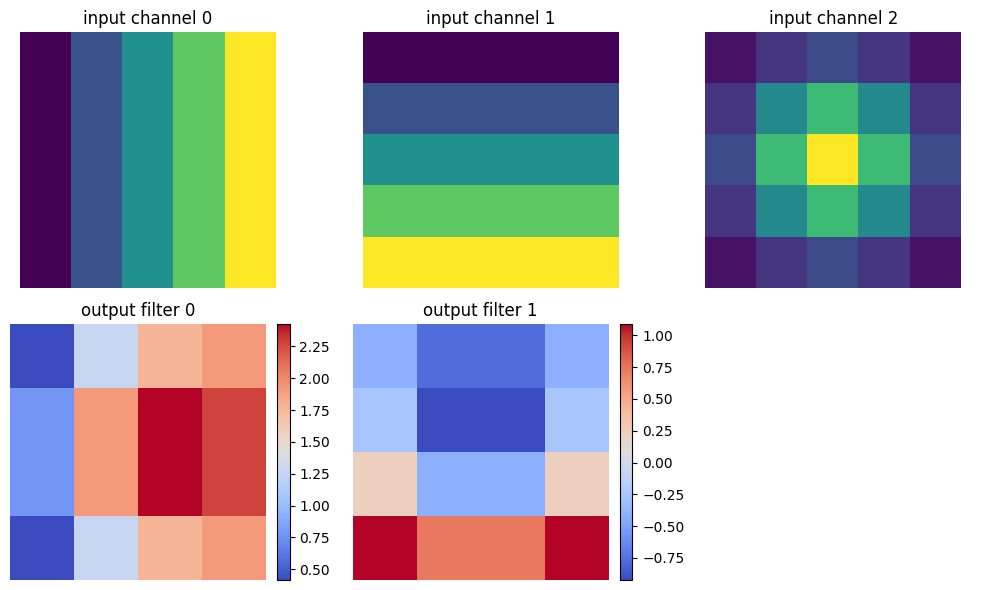

input shape C,H,W: (3, 5, 5)
filters shape F,C,k_h,k_w: (2, 3, 2, 2)
output shape F,H_out,W_out: (2, 4, 4)


In [2]:
# Pseudo-code:
#   1. create a toy three-channel input
#   2. define two multi-channel filters
#   3. slide each filter over the input
#   4. visualize input channels and output feature maps

# Multi-channel convolution with multiple filters from scratch.
# Setup: imports and initial values for this cell.
import numpy as np
import matplotlib.pyplot as plt

grid = np.linspace(0.0, 1.0, 5)
channel_0 = np.tile(grid, (5, 1))
channel_1 = channel_0.T
channel_2 = np.exp(-6.0 * ((channel_0 - 0.5) ** 2 + (channel_1 - 0.5) ** 2))
X = np.stack([channel_0, channel_1, channel_2])

filters = np.array([
    [
        [[1, 0], [1, 0]],
        [[0, 0], [0, 0]],
        [[0.5, 0.5], [0.5, 0.5]],
    ],
    [
        [[0, 0], [0, 0]],
        [[1, 1], [0, 0]],
        [[-0.5, -0.5], [-0.5, -0.5]],
    ],
], dtype=float)

stride = 1
n_filters, n_channels, k_h, k_w = filters.shape
out_h = (X.shape[1] - k_h) // stride + 1
out_w = (X.shape[2] - k_w) // stride + 1
Y = np.zeros((n_filters, out_h, out_w))

for filter_id in range(n_filters):
    for row in range(out_h):
        for col in range(out_w):
            patch = X[:, row:row + k_h, col:col + k_w]
            Y[filter_id, row, col] = np.sum(patch * filters[filter_id])

fig, axes = plt.subplots(2, 3, figsize=(10, 6))
for channel in range(3):
    axes[0, channel].imshow(X[channel], cmap="viridis", vmin=0, vmax=1)
    axes[0, channel].set_title(f"input channel {channel}")
    axes[0, channel].axis("off")

for filter_id in range(2):
    im = axes[1, filter_id].imshow(Y[filter_id], cmap="coolwarm")
    axes[1, filter_id].set_title(f"output filter {filter_id}")
    axes[1, filter_id].axis("off")
    fig.colorbar(im, ax=axes[1, filter_id], fraction=0.046, pad=0.04)
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()

print("input shape C,H,W:", X.shape)
print("filters shape F,C,k_h,k_w:", filters.shape)
print("output shape F,H_out,W_out:", Y.shape)


## From Convolution to Quanvolution

A **quanvolutional layer** keeps the sliding-window idea of a CNN, but replaces the local classical filter computation with a quantum subroutine.

For a local patch $P$, the filter has three conceptual stages:

1. **Encoding**

   $$
   P \longmapsto |\psi_{\mathrm{in}}(P)\rangle
   =
   E(P)|0\cdots 0\rangle.
   $$

2. **Quantum transformation**

   $$
   |\psi_{\mathrm{out}}(P)\rangle
   =
   U |\psi_{\mathrm{in}}(P)\rangle.
   $$

3. **Decoding**

   $$
   z_r(P)
   =
   \langle \psi_{\mathrm{out}}(P)|O_r|\psi_{\mathrm{out}}(P)\rangle.
   $$

The decoded values $z_r(P)$ become output channels at the corresponding spatial location.

In the presentation, this is the main hybrid-QML idea: the quanvolutional layer is a quantum feature extractor inserted where a classical CNN would use a convolutional layer.


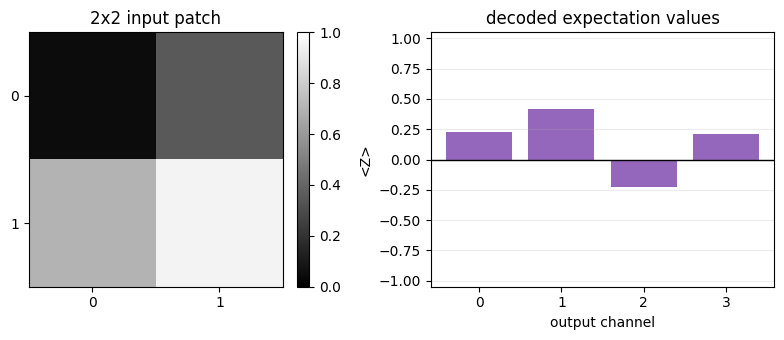

encoded angles: [0.157 1.1   2.199 2.985]
decoded output channels: [ 0.228  0.421 -0.227  0.215]


In [3]:
# Pseudo-code:
#   1. create one 2x2 image patch
#   2. encode patch values as RY rotations on four qubits
#   3. apply a shallow entangling quantum circuit
#   4. decode the quantum state with Pauli-Z expectations

# One quanvolutional filter applied to one image patch.
# Setup: imports and initial values for this cell.
import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml

patch = np.array([
    [0.05, 0.35],
    [0.70, 0.95],
])
patch_angles = np.pi * patch.ravel()
weights = np.array([
    [0.31, -0.22],
    [0.17, 0.48],
    [-0.41, 0.13],
    [0.29, -0.36],
])

dev = qml.device("default.qubit", wires=4)

@qml.qnode(dev)
def quantum_filter(features, circuit_weights):
    for wire in range(4):
        qml.RY(features[wire], wires=wire)
    for wire in range(4):
        qml.RX(circuit_weights[wire, 0], wires=wire)
        qml.RZ(circuit_weights[wire, 1], wires=wire)
    for wire in range(3):
        qml.CNOT(wires=[wire, wire + 1])
    qml.CNOT(wires=[3, 0])
    return tuple(qml.expval(qml.PauliZ(wire)) for wire in range(4))

decoded = np.array(quantum_filter(patch_angles, weights), dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(8.5, 3.5))
im = axes[0].imshow(patch, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("2x2 input patch")
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

axes[1].bar(range(4), decoded, color="tab:purple")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("decoded expectation values")
axes[1].set_xlabel("output channel")
axes[1].set_ylabel("<Z>")
axes[1].set_ylim(-1.05, 1.05)
axes[1].grid(alpha=0.25, axis="y")

plt.tight_layout()
plt.show()

print("encoded angles:", np.round(patch_angles, 3))
print("decoded output channels:", np.round(decoded, 3))


## A Quanvolutional Layer

A quanvolutional layer applies the same quantum filter to every local patch, just as a CNN applies the same classical filter across the image.

For an image of size $H \times W$, patch size $k \times k$, stride $s$, and no padding:

$$
H_{\mathrm{out}}
=
\left\lfloor \frac{H-k}{s} \right\rfloor + 1,
\qquad
W_{\mathrm{out}}
=
\left\lfloor \frac{W-k}{s} \right\rfloor + 1.
$$

If each quantum filter returns $R$ expectation values, then the output has shape

$$
H_{\mathrm{out}} \times W_{\mathrm{out}} \times R.
$$

This is why quanvolution can be inserted before an ordinary classical classifier: the quantum layer simply produces a new stack of feature maps.


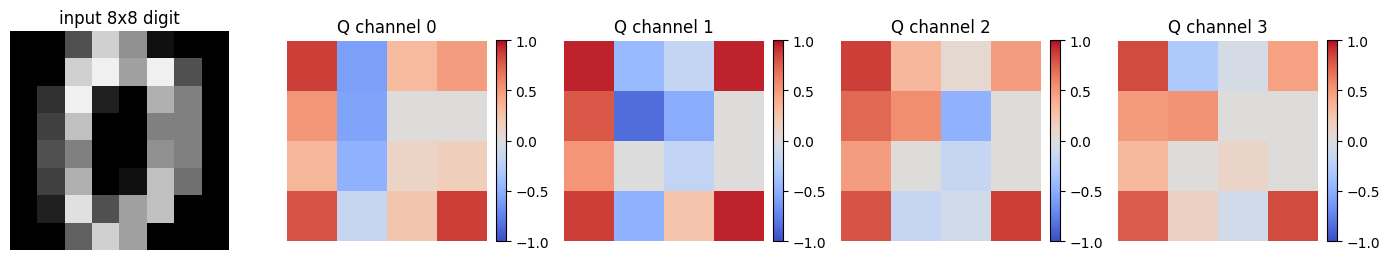

input image shape: (8, 8)
quanvolution output shape H_out,W_out,channels: (4, 4, 4)
quantum circuit executions: 16


In [4]:
# Pseudo-code:
#   1. load a small 8x8 digit image
#   2. slide a 2x2 quantum filter over non-overlapping patches
#   3. store four expectation values per patch
#   4. visualize the produced quanvolutional feature maps

# Quanvolutional layer on one image from the sklearn digits dataset.
# Setup: imports and initial values for this cell.
import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml
from sklearn.datasets import load_digits

digits = load_digits()
image = digits.images[0] / 16.0
patch_size = 2
stride = 2
weights = np.array([
    [0.31, -0.22],
    [0.17, 0.48],
    [-0.41, 0.13],
    [0.29, -0.36],
])

dev = qml.device("default.qubit", wires=4)

@qml.qnode(dev)
def quantum_filter(features, circuit_weights):
    for wire in range(4):
        qml.RY(features[wire], wires=wire)
    for wire in range(4):
        qml.RX(circuit_weights[wire, 0], wires=wire)
        qml.RZ(circuit_weights[wire, 1], wires=wire)
    for wire in range(3):
        qml.CNOT(wires=[wire, wire + 1])
    qml.CNOT(wires=[3, 0])
    return tuple(qml.expval(qml.PauliZ(wire)) for wire in range(4))

out_h = (image.shape[0] - patch_size) // stride + 1
out_w = (image.shape[1] - patch_size) // stride + 1
channels = 4
quanv = np.zeros((out_h, out_w, channels))

for row in range(out_h):
    for col in range(out_w):
        patch = image[row * stride:row * stride + patch_size, col * stride:col * stride + patch_size]
        features = np.pi * patch.ravel()
        quanv[row, col] = np.array(quantum_filter(features, weights), dtype=float)

fig, axes = plt.subplots(1, 5, figsize=(14, 3))
axes[0].imshow(image, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("input 8x8 digit")
axes[0].axis("off")

for channel in range(channels):
    im = axes[channel + 1].imshow(quanv[:, :, channel], cmap="coolwarm", vmin=-1, vmax=1)
    axes[channel + 1].set_title(f"Q channel {channel}")
    axes[channel + 1].axis("off")
    fig.colorbar(im, ax=axes[channel + 1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

print("input image shape:", image.shape)
print("quanvolution output shape H_out,W_out,channels:", quanv.shape)
print("quantum circuit executions:", out_h * out_w)


## Applied Example: Quanvolutional Features for Classification

The original quanvolution paper treats the quantum circuit as a feature extractor. The circuit may be random or structured, and the classical model learns from the resulting feature maps.

Here we use a small binary task from the `sklearn` digits dataset:

- class 0 versus class 1,
- each image is $8 \times 8$,
- a fixed 2x2 quantum filter is applied with stride 2,
- the resulting $4 \times 4 \times 4$ tensor is flattened,
- logistic regression is trained from scratch.

This is not meant to prove quantum advantage. It demonstrates the **hybrid architecture**: a quantum local feature extractor followed by a classical trainable head.


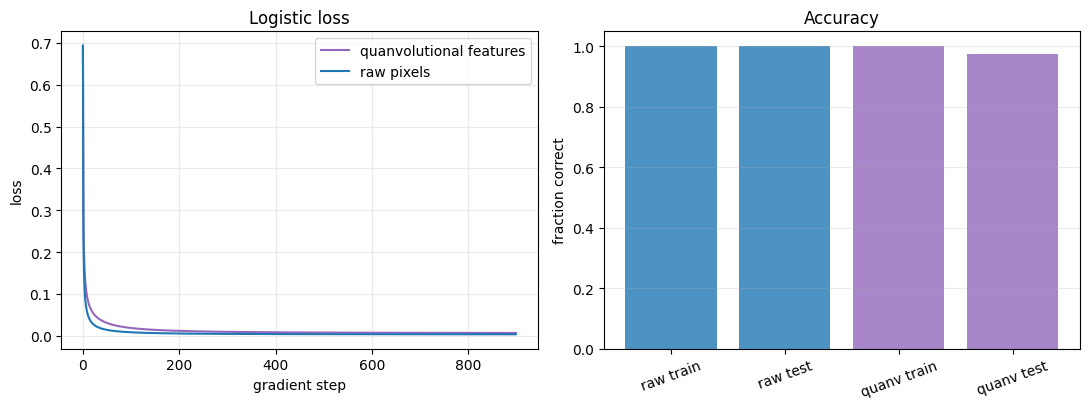

raw pixel train/test accuracy: 1.0 1.0
quanvolution train/test accuracy: 1.0 0.975
quanvolution features shape: (90, 64)
total quantum circuit executions: 2080


In [5]:
# Pseudo-code:
#   1. load a binary subset of the digits dataset
#   2. transform each image with a fixed quanvolutional layer
#   3. train logistic regression from scratch on quantum features
#   4. compare against logistic regression on raw pixels

# Fixed quanvolutional feature extractor plus classical logistic classifier.
# Setup: imports and initial values for this cell.
import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml
from sklearn.datasets import load_digits

rng = np.random.default_rng(73)
digits = load_digits()
mask = (digits.target == 0) | (digits.target == 1)
images = digits.images[mask] / 16.0
labels = digits.target[mask].astype(float)

class0 = np.where(labels == 0)[0]
class1 = np.where(labels == 1)[0]
class0 = rng.permutation(class0)
class1 = rng.permutation(class1)
train_idx = np.r_[class0[:45], class1[:45]]
test_idx = np.r_[class0[45:65], class1[45:65]]
train_idx = rng.permutation(train_idx)
test_idx = rng.permutation(test_idx)

X_train_images = images[train_idx]
y_train = labels[train_idx]
X_test_images = images[test_idx]
y_test = labels[test_idx]

weights = np.array([
    [0.31, -0.22],
    [0.17, 0.48],
    [-0.41, 0.13],
    [0.29, -0.36],
])

dev = qml.device("default.qubit", wires=4)

@qml.qnode(dev)
def quantum_filter(features, circuit_weights):
    for wire in range(4):
        qml.RY(features[wire], wires=wire)
    for wire in range(4):
        qml.RX(circuit_weights[wire, 0], wires=wire)
        qml.RZ(circuit_weights[wire, 1], wires=wire)
    for wire in range(3):
        qml.CNOT(wires=[wire, wire + 1])
    qml.CNOT(wires=[3, 0])
    return tuple(qml.expval(qml.PauliZ(wire)) for wire in range(4))

def quanvolve_image(image, circuit_weights):
    patch_size = 2
    stride = 2
    out_h = (image.shape[0] - patch_size) // stride + 1
    out_w = (image.shape[1] - patch_size) // stride + 1
    output = np.zeros((out_h, out_w, 4))
    for row in range(out_h):
        for col in range(out_w):
            patch = image[row * stride:row * stride + patch_size, col * stride:col * stride + patch_size]
            features = np.pi * patch.ravel()
            output[row, col] = np.array(quantum_filter(features, circuit_weights), dtype=float)
    return output

X_train_quanv = np.array([quanvolve_image(image, weights).ravel() for image in X_train_images])
X_test_quanv = np.array([quanvolve_image(image, weights).ravel() for image in X_test_images])
X_train_raw = X_train_images.reshape(len(X_train_images), -1)
X_test_raw = X_test_images.reshape(len(X_test_images), -1)

def standardize(train, test):
    mean = train.mean(axis=0)
    scale = train.std(axis=0) + 1e-9
    return (train - mean) / scale, (test - mean) / scale

X_train_quanv, X_test_quanv = standardize(X_train_quanv, X_test_quanv)
X_train_raw, X_test_raw = standardize(X_train_raw, X_test_raw)

def train_logistic(X_train, y_train, X_test, y_test, steps=900, eta=0.18, l2=1e-3):
    X_train_design = np.column_stack([np.ones(len(X_train)), X_train])
    X_test_design = np.column_stack([np.ones(len(X_test)), X_test])
    theta = np.zeros(X_train_design.shape[1])
    loss_history = []
    for step in range(steps):
        logits = X_train_design @ theta
        probabilities = 1.0 / (1.0 + np.exp(-np.clip(logits, -35.0, 35.0)))
        eps = 1e-12
        loss = -np.mean(y_train * np.log(probabilities + eps) + (1.0 - y_train) * np.log(1.0 - probabilities + eps))
        loss = loss + 0.5 * l2 * np.sum(theta[1:] ** 2)
        gradient = (X_train_design.T @ (probabilities - y_train)) / len(y_train)
        gradient[1:] = gradient[1:] + l2 * theta[1:]
        theta = theta - eta * gradient
        loss_history.append(loss)

    train_pred = (1.0 / (1.0 + np.exp(-np.clip(X_train_design @ theta, -35.0, 35.0))) >= 0.5).astype(float)
    test_pred = (1.0 / (1.0 + np.exp(-np.clip(X_test_design @ theta, -35.0, 35.0))) >= 0.5).astype(float)
    train_accuracy = np.mean(train_pred == y_train)
    test_accuracy = np.mean(test_pred == y_test)
    return loss_history, train_accuracy, test_accuracy

quanv_loss, quanv_train_acc, quanv_test_acc = train_logistic(X_train_quanv, y_train, X_test_quanv, y_test)
raw_loss, raw_train_acc, raw_test_acc = train_logistic(X_train_raw, y_train, X_test_raw, y_test)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].plot(quanv_loss, color="tab:purple", label="quanvolutional features")
axes[0].plot(raw_loss, color="tab:blue", label="raw pixels")
axes[0].set_title("Logistic loss")
axes[0].set_xlabel("gradient step")
axes[0].set_ylabel("loss")
axes[0].grid(alpha=0.25)
axes[0].legend()

labels_bar = ["raw train", "raw test", "quanv train", "quanv test"]
values = [raw_train_acc, raw_test_acc, quanv_train_acc, quanv_test_acc]
axes[1].bar(labels_bar, values, color=["tab:blue", "tab:blue", "tab:purple", "tab:purple"], alpha=0.8)
axes[1].set_ylim(0, 1.05)
axes[1].set_title("Accuracy")
axes[1].set_ylabel("fraction correct")
axes[1].grid(alpha=0.25, axis="y")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

print("raw pixel train/test accuracy:", round(float(raw_train_acc), 3), round(float(raw_test_acc), 3))
print("quanvolution train/test accuracy:", round(float(quanv_train_acc), 3), round(float(quanv_test_acc), 3))
print("quanvolution features shape:", X_train_quanv.shape)
print("total quantum circuit executions:", (len(X_train_images) + len(X_test_images)) * 16)


## Design Knobs, Pros, and Cons

The presentation emphasizes that quanvolutional layers are flexible. The main design choices are:

| Design choice | Meaning |
|---|---|
| Patch size | Determines number of encoded pixels and qubits |
| Encoding | Basis, amplitude, angle, or custom image encoding |
| Circuit unitary $U$ | Random, structured, trainable, or problem-inspired |
| Observables | Which measurements become output channels |
| Number of filters | How many independent quantum circuits or parameter sets are used |
| Layer stacking | Whether several quanvolutional layers are composed |
| Classical head | Logistic regression, dense neural network, CNN layers, etc. |

Practical strengths:

- hybrid classical-quantum architecture,
- no QRAM requirement because patches are loaded classically,
- low qubit count for small patches,
- shallow circuits can be used.

Practical challenges:

- choosing a useful encoding/decoding interface,
- many quantum circuit executions,
- no automatic guarantee of quantum advantage,
- possible trainability issues if the quantum filter becomes too deep or fully variational.


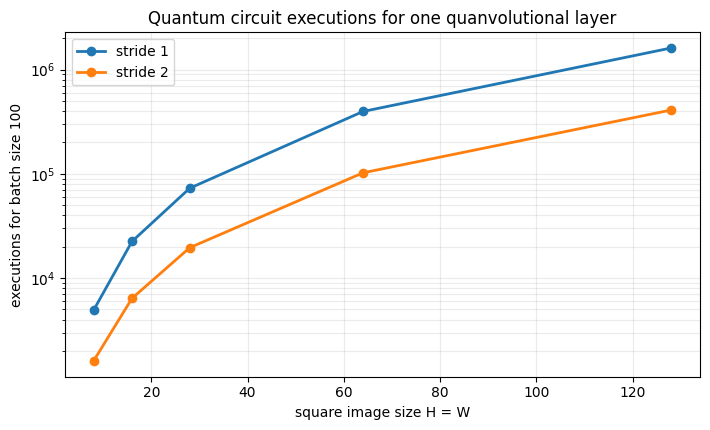

stride=1: executions for 28x28 batch = 72900
stride=2: executions for 28x28 batch = 19600


In [6]:
# Pseudo-code:
#   1. compute output sizes for different image sizes
#   2. count required quantum circuit executions
#   3. compare stride choices
#   4. visualize the scaling bottleneck

# Circuit-execution count for a quanvolutional layer.
# Setup: imports and initial values for this cell.
import numpy as np
import matplotlib.pyplot as plt

image_sizes = np.array([8, 16, 28, 64, 128])
patch_size = 2
strides = [1, 2]
n_filters = 1
batch_size = 100

execution_counts = {}
for stride in strides:
    out_sizes = ((image_sizes - patch_size) // stride) + 1
    patches_per_image = out_sizes**2
    execution_counts[stride] = batch_size * n_filters * patches_per_image

plt.figure(figsize=(7.2, 4.4))
for stride in strides:
    plt.plot(image_sizes, execution_counts[stride], marker="o", linewidth=2, label=f"stride {stride}")
plt.yscale("log")
plt.title("Quantum circuit executions for one quanvolutional layer")
plt.xlabel("square image size H = W")
plt.ylabel("executions for batch size 100")
plt.grid(alpha=0.25, which="both")
plt.legend()
plt.tight_layout()
plt.show()

for stride in strides:
    print(f"stride={stride}: executions for 28x28 batch =", int(execution_counts[stride][image_sizes.tolist().index(28)]))


## Summary

A quanvolutional neural network keeps the CNN idea of local filters, stride, padding, and feature maps, but replaces the local filter computation with a quantum circuit.

The core transformation is:

$$
\text{local patch}
\xrightarrow{\text{encoding}}
\text{quantum state}
\xrightarrow{\text{unitary}}
\text{transformed quantum state}
\xrightarrow{\text{measurement}}
\text{classical feature channels}.
$$

The resulting feature maps can feed into ordinary classical layers. This makes quanvolution a natural example of the hybrid-QML paradigm: quantum circuits act as local feature extractors, while classical optimization and classification remain responsible for the final task.
